In [934]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from scipy.stats import spearmanr
from joblib import Parallel, delayed
import warnings
import gc
import matplotlib.pyplot as plt
import argparse
from tqdm.auto import tqdm
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
import pandas as pd
import numpy as np
from itertools import permutations
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer
from pandas.api.types import (
    is_numeric_dtype,
    is_categorical_dtype,
    is_object_dtype
)



In [1072]:
#path_to_sim = "/Users/zhangyuhan/Downloads/df_0_1_2_17072025_204803_ncells_10000_fan_out_6bc62096.csv"  # ← CHANGE this
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_row_0_1_14072025_220943_ncells_10000_A_B_261640e4.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_row_0_1_14072025_224456_ncells_10000_A_and_B_9f4b14e4.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_row_0_1_2_16072025_140816_ncells_10000_A_to_C_B_to_C_55d9c31b.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_row_10_11_12_14072025_233548_ncells_10000_A_to_B_to_C_73acd23c.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/df_rows_0_1_2_29072025_173447_ncells_5000_Feed_forward_b64a8f7c.csv"
path_to_sim="/Users/zhangyuhan/Downloads/df_rows_3_4_5_29072025_171529_ncells_5000_Fan_out_non_symmetric_575cf32b.csv"

#A to B
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_row_0_1_14072025_175926_ncells_10000_A_to_B_9c7f0cd0.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_211315_ncells_10000_A_to_B_1_b33bf4a1.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_211338_ncells_10000_A_to_B_0_d11eab90.csv" 
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_211417_ncells_10000_A_to_B_2_a8670e68.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_211415_ncells_10000_A_to_B_3_65f7eadb.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_214516_ncells_10000_A_to_B_4_940fecc8.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_214634_ncells_10000_A_to_B_5_5381f551.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_214821_ncells_10000_A_to_B_6_e58d1039.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_214814_ncells_10000_A_to_B_7_31b6d4e7.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_222015_ncells_10000_A_to_B_8_f8fbdfa4.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_221920_ncells_10000_A_to_B_9_caa1186a.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_222041_ncells_10000_A_to_B_10_4cac1354.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_222238_ncells_10000_A_to_B_11_cf333ec0.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_225150_ncells_10000_A_to_B_12_807c5c3f.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_225438_ncells_10000_A_to_B_13_15f9119d.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_225254_ncells_10000_A_to_B_14_dbae521c.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_225610_ncells_10000_A_to_B_15_889ddb61.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_232411_ncells_10000_A_to_B_16_7cbbc6bd.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/simulations/df_rows_0_1_16072025_232626_ncells_10000_A_to_B_17_845b4345.csv"

#A B
#path_to_sim="/Users/zhangyuhan/Downloads/df_rows_0_1_16072025_234318_ncells_10000_A_B_0_173de525.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/df_rows_0_1_16072025_234339_ncells_10000_A_B_1_a8732793.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/df_rows_0_1_16072025_234405_ncells_10000_A_B_3_a4fb82ac.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/df_rows_0_1_16072025_234437_ncells_10000_A_B_2_7363b326.csv" 
#path_to_sim="/Users/zhangyuhan/Downloads/df_rows_0_1_16072025_235723_ncells_10000_A_B_5_e85c1617.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/df_rows_0_1_16072025_235735_ncells_10000_A_B_4_2453ac3b.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/df_rows_0_1_16072025_235751_ncells_10000_A_B_6_2b098b5f.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/df_rows_0_1_16072025_235932_ncells_10000_A_B_7_b5f99a7e.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/df_rows_0_1_17072025_001112_ncells_10000_A_B_8_5832cb4b.csv"
#path_to_sim="/Users/zhangyuhan/Downloads/df_rows_0_1_17072025_001113_ncells_10000_A_B_10_5cb911f5.csv"
df = pd.read_csv(path_to_sim)

output_folder = "/Users/zhangyuhan/Desktop"

📊 Summary Statistics:
mean                 0.0053
median               0.0054
min                  0.0037
max                  0.0066
25% (Q1)             0.0048
50% (Q2 / median)    0.0054
75% (Q3)             0.0059
IQR                  0.0011
lower_whisker        0.0031
upper_whisker        0.0077
dtype: float64


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


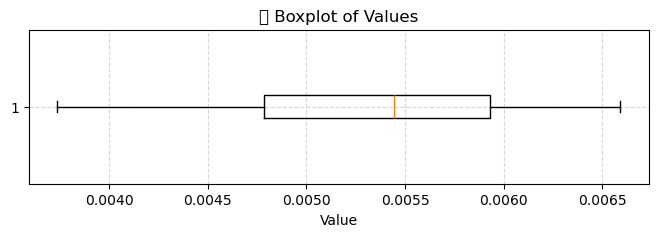

📊 Summary Statistics:
mean                 0.0018
median               0.0018
min                  0.0012
max                  0.0024
25% (Q1)             0.0015
50% (Q2 / median)    0.0018
75% (Q3)             0.0020
IQR                  0.0006
lower_whisker        0.0006
upper_whisker        0.0029
dtype: float64


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


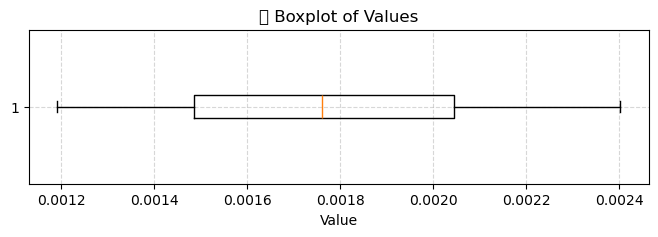

In [1073]:
#A to B
values = np.array([0.005911, 0.00575, 0.006592, 0.004211, 0.00576, 0.005952, 0.005952, 0.004417, 0.005445, 0.003734, 0.006280, 0.004779, 0.004919, 0.004789, 0.004807, 0.006212, 0.005454, 0.004774, 0.005062])

# --- Step 1: Calculate Statistics ---
mean_val = np.mean(values)
median_val = np.median(values)
min_val = np.min(values)
max_val = np.max(values)

q1 = np.percentile(values, 25)
q2 = np.percentile(values, 50)
q3 = np.percentile(values, 75)
iqr = q3 - q1

# Tukey boxplot whiskers
lower_whisker = q1 - 1.5 * iqr
upper_whisker = q3 + 1.5 * iqr

# --- Step 2: Create Summary ---
summary = {
    'mean': mean_val,
    'median': median_val,
    'min': min_val,
    'max': max_val,
    '25% (Q1)': q1,
    '50% (Q2 / median)': q2,
    '75% (Q3)': q3,
    'IQR': iqr,
    'lower_whisker': lower_whisker,
    'upper_whisker': upper_whisker,
}
print("📊 Summary Statistics:")
print(pd.Series(summary).round(4))

# --- Step 3: Boxplot ---
plt.figure(figsize=(8, 2))
plt.boxplot(values, vert=False)
plt.title("📦 Boxplot of Values")
plt.xlabel("Value")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#A to B
values = np.array([0.002356, 0.002124, 0.001281, 0.001760, 0.001574, 0.001891, 0.002402, 0.001965, 0.001539, 0.001429, 0.00119])

# --- Step 1: Calculate Statistics ---
mean_val = np.mean(values)
median_val = np.median(values)
min_val = np.min(values)
max_val = np.max(values)

q1 = np.percentile(values, 25)
q2 = np.percentile(values, 50)
q3 = np.percentile(values, 75)
iqr = q3 - q1

# Tukey boxplot whiskers
lower_whisker = q1 - 1.5 * iqr
upper_whisker = q3 + 1.5 * iqr

# --- Step 2: Create Summary ---
summary = {
    'mean': mean_val,
    'median': median_val,
    'min': min_val,
    'max': max_val,
    '25% (Q1)': q1,
    '50% (Q2 / median)': q2,
    '75% (Q3)': q3,
    'IQR': iqr,
    'lower_whisker': lower_whisker,
    'upper_whisker': upper_whisker,
}
print("📊 Summary Statistics:")
print(pd.Series(summary).round(4))

# --- Step 3: Boxplot ---
plt.figure(figsize=(8, 2))
plt.boxplot(values, vert=False)
plt.title("📦 Boxplot of Values")
plt.xlabel("Value")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [1074]:
t1, t2 = 5, 20

# mRNA columns
mRNA_cols = [col for col in df.columns if col.endswith("_mRNA")]

# t1 
df_t1 = df[df["time_step"] == t1]
rep_0_t1 = df_t1[df_t1["replicate"] == 1].reset_index(drop=True)[mRNA_cols]
rep_1_t1 = df_t1[df_t1["replicate"] == 2].reset_index(drop=True)[mRNA_cols]
expr_t1_all = pd.concat([rep_0_t1, rep_1_t1]).reset_index(drop=True)

# t2
df_t2 = df[df["time_step"] == t2]
rep_0_t2 = df_t2[df_t2["replicate"] == 1].reset_index(drop=True)[mRNA_cols]
rep_1_t2 = df_t2[df_t2["replicate"] == 2].reset_index(drop=True)[mRNA_cols]
expr_t2_all = pd.concat([rep_0_t2, rep_1_t2]).reset_index(drop=True)



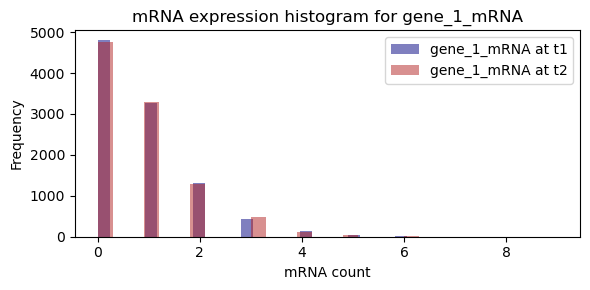

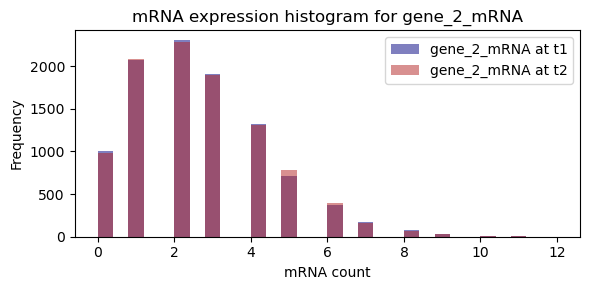

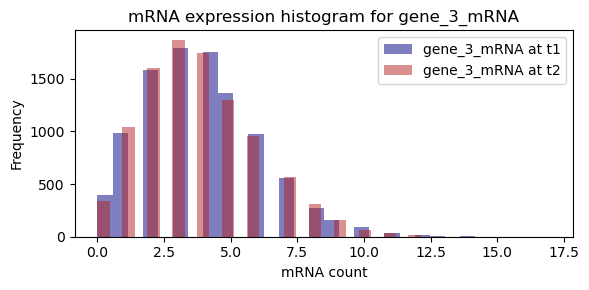

In [1075]:
import matplotlib.pyplot as plt

# Plot histogram for each gene at t1 and t2
for gene in mRNA_cols:
    plt.figure(figsize=(6, 3))
    plt.hist(expr_t1_all[gene], bins=30, alpha=0.5, label=f"{gene} at t1", color='navy')
    plt.hist(expr_t2_all[gene], bins=30, alpha=0.5, label=f"{gene} at t2", color='firebrick')
    plt.title(f"mRNA expression histogram for {gene}")
    plt.xlabel("mRNA count")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [1003]:
# Loop over each mRNA column
for gene in mRNA_cols:
    print(f"\n Time {t1} — {gene} mRNA counts:")
    freq_t1 = expr_t1_all[gene].value_counts().sort_index()
    print(freq_t1.to_string())

    print(f"\n Time {t2} — {gene} mRNA counts:")
    freq_t2 = expr_t2_all[gene].value_counts().sort_index()
    print(freq_t2.to_string())

    print("-" * 60)



 Time 5 — gene_1_mRNA mRNA counts:
gene_1_mRNA
0    4846
1    3204
2    1357
3     442
4     118
5      28
6       4
7       1

 Time 10 — gene_1_mRNA mRNA counts:
gene_1_mRNA
0    4854
1    3186
2    1314
3     486
4     114
5      33
6      11
7       1
8       1
------------------------------------------------------------

 Time 5 — gene_2_mRNA mRNA counts:
gene_2_mRNA
0      585
1     1387
2     2030
3     2008
4     1573
5     1124
6      678
7      329
8      166
9       73
10      32
11      11
12       2
13       1
14       1

 Time 10 — gene_2_mRNA mRNA counts:
gene_2_mRNA
0      594
1     1420
2     1975
3     2003
4     1623
5     1132
6      615
7      352
8      184
9       63
10      26
11      11
12       2
------------------------------------------------------------

 Time 5 — gene_3_mRNA mRNA counts:
gene_3_mRNA
0      418
1     1201
2     1842
3     1950
4     1663
5     1260
6      823
7      437
8      230
9      104
10      52
11       9
12       6
13       3
14  

In [1055]:
# Count unique expression values per gene at t1
bins_t1 = expr_t1_all.nunique()

# Count unique expression values per gene at t2
bins_t2 = expr_t2_all.nunique()

# Combine into one table for easy comparison
bins_df = pd.DataFrame({
    't1_bins': bins_t1,
    't2_bins': bins_t2
})

print(bins_df)


             t1_bins  t2_bins
gene_1_mRNA       11       10
gene_2_mRNA       19       17
gene_3_mRNA       18       19


In [940]:
pd.crosstab(expr_t1_all["gene_1_mRNA"], expr_t1_all["gene_2_mRNA"])

gene_2_mRNA,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,20
gene_1_mRNA,,,,,,,,,,,,,,,,,,,
0,226,638,1037,1349,1331,1236,860,619,384,220,104,44,25,14,2,3,1,1,1
1,137,455,802,988,1087,1048,802,517,331,213,111,58,27,14,7,1,2,0,0
2,61,203,359,499,532,531,429,304,189,98,58,32,16,9,1,2,0,0,0
3,31,60,150,204,231,233,155,126,68,50,26,18,5,1,0,1,1,0,0
4,7,20,63,62,64,64,53,31,35,18,7,7,0,1,0,0,0,0,0
5,2,8,16,20,17,16,18,14,9,9,3,2,0,1,0,0,0,0,0
6,1,3,4,9,6,3,4,3,3,1,1,0,0,0,0,0,0,0,0
7,0,0,2,1,5,2,1,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,1,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0


In [941]:
(expr_t1_all == 0).mean().round(3)


gene_1_mRNA    0.405
gene_2_mRNA    0.023
gene_3_mRNA    0.023
dtype: float64

In [1045]:
#Step 1: gene-gene MI calculation
    #1. input gene expression data (gene_1_mRNA, gene_2_mRNA, gene_2_mRNA, ...)
    #2. compute observed MI for all gene pairs (e.g., gene1-gene2, gene1-gene3, gene2-gene3, ...)
    #3. initialze permutation test (e.g., N = 1000 permutations)
    #4. repeat N Times to build a null distribution for each gene pair:
        #a. shuffle one gene in a pair (e.g., gene2)
            #if we have n genes, there would be n(n-1)/2 unique gene pairs
            #shuffle gene_j for each gene pair (gene_i, gene_j)
        #b. compute MI for all pairs
            #compute MI between gene_i and shuffled gene_j
        #c. store MI values
    #6. compare observed MI to each null distribution and calculate the p-values for each gene pair  

In [1076]:
def calc_joint_marginal(df, col1, col2):
    joint_counts = pd.crosstab(df[col1], df[col2])
    total = joint_counts.values.sum()
    joint_prob = joint_counts / total
    x_prob = joint_prob.sum(axis=1)
    y_prob = joint_prob.sum(axis=0)
    return joint_prob, x_prob, y_prob

def mutual_information_discrete(joint_prob, x_prob, y_prob, log_base=np.e):
    mi = 0.0
    log_func = lambda x: np.log(x) / np.log(log_base)
    for x in joint_prob.index:
        for y in joint_prob.columns:
            pxy = joint_prob.at[x, y]
            if pxy > 0:
                px = x_prob.at[x]
                py = y_prob.at[y]
                mi += pxy * log_func(pxy / (px * py))
    return mi

def entropy(prob_series, log_base=np.e):
    log_func = lambda x: np.log(x) / np.log(log_base)
    return -np.sum(prob_series[prob_series > 0] * prob_series[prob_series > 0].apply(log_func))


#optional normalization to make the diagonal equal to 1
# def normalized_mi(joint_prob, x_prob, y_prob, log_base=np.e):
#     mi = mutual_information_discrete(joint_prob, x_prob, y_prob, log_base)
#     Hx = entropy(x_prob, log_base)
#     Hy = entropy(y_prob, log_base)
#     avg_entropy = (Hx + Hy) / 2
#     return mi / avg_entropy if avg_entropy > 0 else 0.0


def compute_custom_mi_matrix(df, normalized=False, log_base=2):
    # Allow numeric (int/float), categorical, or object columns
    valid = df.dtypes.apply(
        lambda dt: is_numeric_dtype(dt)
                   or is_categorical_dtype(dt)
                   or is_object_dtype(dt)
    )
    if not valid.all():
        bad_cols = df.columns[~valid].tolist()
        raise ValueError(f"These columns are not discrete: {bad_cols}")

    genes = df.columns
    mi_matrix = pd.DataFrame(index=genes, columns=genes, dtype=float)

    for i, g1 in enumerate(genes):
        for j, g2 in enumerate(genes[i:], start=i):
            joint, x_prob, y_prob = calc_joint_marginal(df, g1, g2)
            if normalized:
                mi_value = normalized_mi(joint, x_prob, y_prob, log_base)
            else:
                mi_value = mutual_information_discrete(joint, x_prob, y_prob, log_base)
            mi_matrix.at[g1, g2] = mi_value
            mi_matrix.at[g2, g1] = mi_value 

    return mi_matrix



In [1077]:
# Compute MI at t1 and t2
mi_matrix_t1 = compute_custom_mi_matrix(expr_t1_all, normalized=False, log_base=2)
mi_matrix_t2 = compute_custom_mi_matrix(expr_t2_all, normalized=False, log_base=2)

# Optional: Normalized MI
# nmi_matrix_t1 = compute_custom_mi_matrix(expr_t1_all, normalized=True, log_base=2)
# nmi_matrix_t2 = compute_custom_mi_matrix(expr_t2_all, normalized=True, log_base=2)

# Optional: Difference
mi_diff = mi_matrix_t2 - mi_matrix_t1
# nmi_diff = nmi_matrix_t2 - nmi_matrix_t1


print(mi_matrix_t1)
print(mi_matrix_t2)

             gene_1_mRNA  gene_2_mRNA  gene_3_mRNA
gene_1_mRNA     1.745676     0.006500     0.008122
gene_2_mRNA     0.006500     2.775944     0.018750
gene_3_mRNA     0.008122     0.018750     3.129293
             gene_1_mRNA  gene_2_mRNA  gene_3_mRNA
gene_1_mRNA     1.753973     0.007701     0.007744
gene_2_mRNA     0.007701     2.776464     0.018110
gene_3_mRNA     0.007744     0.018110     3.106619


In [1058]:
def entropy(vec):
    _, counts = np.unique(vec, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))


def joint_entropy(x, y):
    joint = np.c_[x, y]
    _, counts = np.unique(joint, axis=0, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))


def conditional_entropy(y, x):
    return joint_entropy(x, y) - entropy(x)


def mutual_information(x, y):
    return entropy(y) - conditional_entropy(y, x)

def compute_mi_at_time(df, time_point, gene1='gene_1_mRNA', gene2='gene_2_mRNA'):
    df_time = df[df["time_step"] == time_point]
    x = df_time[gene1].values
    y = df_time[gene2].values
    mi = mutual_information(x, y)
    print(f" Mutual Information between {gene1} and {gene2} at t={time_point}: {mi:.6f} bits")
    return mi

In [1059]:
def entropy(vec):
    _, counts = np.unique(vec, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def joint_entropy(x, y):
    joint = np.c_[x, y]
    _, counts = np.unique(joint, axis=0, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def conditional_entropy(y, x):
    return joint_entropy(x, y) - entropy(x)

def mutual_information(x, y):
    return entropy(y) - conditional_entropy(y, x)

def compute_mi_matrix_at_time(df, time_point, gene_columns=None):
    """
    Computes mutual information for all gene pairs at a given time point.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        time_point (int): The time step to filter on.
        gene_columns (list of str): List of gene columns to use (e.g., mRNA columns).
                                    If None, uses all columns except 'time_step', 'replicate', etc.

    Returns:
        pd.DataFrame: Symmetric MI matrix.
    """
    df_time = df[df["time_step"] == time_point]

    if gene_columns is None:
        gene_columns = [col for col in df_time.columns if "mRNA" in col]

    mi_matrix = pd.DataFrame(index=gene_columns, columns=gene_columns, dtype=float)

    for i, gene1 in enumerate(gene_columns):
        for j, gene2 in enumerate(gene_columns[i:], start=i):
            x = df_time[gene1].values
            y = df_time[gene2].values
            mi = mutual_information(x, y)
            mi_matrix.at[gene1, gene2] = mi
            mi_matrix.at[gene2, gene1] = mi  # symmetric

    return mi_matrix


In [1060]:
mi_matrix_t1 = compute_mi_matrix_at_time(df, time_point=5)
print(mi_matrix_t1.round(6))



             gene_1_mRNA  gene_2_mRNA  gene_3_mRNA
gene_1_mRNA     1.945141     0.007354     0.007528
gene_2_mRNA     0.007354     3.264416     0.026504
gene_3_mRNA     0.007528     0.026504     3.280350


In [1061]:
##Entropy
def entropy(Y):
    """
    Also known as Shanon Entropy
    Reference: https://en.wikipedia.org/wiki/Entropy_(information_theory)
    """
    unique, count = np.unique(Y, return_counts=True, axis=0)
    prob = count/len(Y)
    en = np.sum((-1)*prob*np.log2(prob))
    return en


#Joint Entropy
def jEntropy(Y,X):
    """
    H(Y;X)
    Reference: https://en.wikipedia.org/wiki/Joint_entropy
    """
    YX = np.c_[Y,X]
    return entropy(YX)

#Conditional Entropy
def cEntropy(Y, X):
    """
    conditional entropy = Joint Entropy - Entropy of X
    H(Y|X) = H(Y;X) - H(X)
    Reference: https://en.wikipedia.org/wiki/Conditional_entropy
    """
    return jEntropy(Y, X) - entropy(X)


#Information Gain
def gain(Y, X):
    """
    Information Gain, I(Y;X) = H(Y) - H(Y|X)
    Reference: https://en.wikipedia.org/wiki/Information_gain_in_decision_trees#Formal_definition
    """
    return entropy(Y) - cEntropy(Y,X)

In [ ]:
#PIDC:
    #1. I(Z; X, Y)= Synergy (Z; X, Y) + Uniquey(Z; X) + Uniquex(Z: Y) + Redundancy(Z; X, Y)
    #2. I spec (z; X) = sum x( p(x|z) (log (1/p(z) - log(1/p(z|x) )) 
    #3. Redundancy (Z; X, Y)= sum z (p(z) min s Ispec (z; S))
    #4. I(X; Z)=Unique(Z; X)+ Redundancy (Z; X, Y)
    #5. II (X; Y; Z)= Synergy (Z; X, Y) - Redundancy (Z; X, Y) -> ineteractiob information: conditioned MI - MI
    #6. Ux, y= sum uniquez (X; Y)/I(X; Y) + sum uniquez (Y; X)/I(X; Y)

In [ ]:
#2
def specific_information(source, target, log_base=2):
    """
    Compute I_spec(z; X) = sum_x p(x|z) * log( p(z|x)/p(z) )
    Returns a Series indexed by each observed state z of `target`.
    """
    joint = pd.DataFrame({'x': source, 'z': target})
    N = len(joint)
    
    p_xz = joint.groupby(['x','z']).size() / N
    p_x  = joint['x'].value_counts() / N
    p_z  = joint['z'].value_counts() / N

    ispec = {}
    for z_val, pz in p_z.items():
        total = 0.0
        if z_val not in p_xz.index.get_level_values('z'):
            ispec[z_val] = 0.0
            continue
        xs = p_xz.xs(z_val, level='z').index
        for x_val in xs:
            pxz = p_xz.loc[(x_val, z_val)]
            p_x_given_z = pxz / pz
            p_z_given_x = pxz / p_x[x_val]
            total += p_x_given_z * (np.log(p_z_given_x / pz) / np.log(log_base))
        ispec[z_val] = total

    return pd.Series(ispec, name=f"I_spec(z;X)")

def compute_state_specific_info(df, target_gene, log_base=2):
    """
    For a target gene Z, return a DataFrame:
      - Rows = each z value
      - Columns = I_spec(z; X_i) for all source genes X_i
    """
    genes = df.columns
    target = df[target_gene].values
    result = {}

    for src in genes:
        if src == target_gene:
            p_z = df[target_gene].value_counts() / len(df)
            result[src] = np.log(1 / p_z) / np.log(log_base)
        else:
            result[src] = specific_information(df[src].values, target, log_base)

    df_ispec = pd.DataFrame(result)
    df_ispec.index.name = target_gene
    return df_ispec

# --- Main Loop ---
def compute_pidc_tensor(df_mrna, log_base=2):
    tensor_dict = {}
    for target_gene in df_mrna.columns:
        print(f" Computing I_spec for target: {target_gene}")
        tensor_dict[target_gene] = compute_state_specific_info(df_mrna, target_gene, log_base)
    return tensor_dict

# Example usage
df_mrna = df[[c for c in df.columns if '_mRNA' in c]]
pidc_tensor = compute_pidc_tensor(df_mrna)

for target_gene in df_mrna.columns:
    print(f"\n Target Gene: {target_gene}")
    state_specific_df = compute_state_specific_info(df_mrna, target_gene)
    print(state_specific_df.round(4))  # Or .head() if it's too big




 Computing I_spec for target: gene_1_mRNA
 Computing I_spec for target: gene_2_mRNA
 Computing I_spec for target: gene_3_mRNA

 Target Gene: gene_1_mRNA
             gene_1_mRNA  gene_2_mRNA  gene_3_mRNA
gene_1_mRNA                                       
0                 1.0591       0.0009       0.0012
1                 1.6303       0.0002       0.0003
2                 2.8989       0.0021       0.0027
3                 4.4874       0.0040       0.0065
4                 6.2089       0.0104       0.0088
5                 8.1031       0.0083       0.0195
6                 9.9687       0.0584       0.0240
7                12.1610       0.2738       0.0603
8                14.7325       0.5083       0.4203
9                16.9024       1.5629       1.2860
10               18.9024       3.7748       2.5429

 Target Gene: gene_2_mRNA
             gene_1_mRNA  gene_2_mRNA  gene_3_mRNA
gene_2_mRNA                                       
2                 0.0001       2.1085       0.0004
1   

In [1100]:
# Specific information calculator
def compute_specific_info(X, Z, n_bins=6):
    df_local = pd.DataFrame({'X': X, 'Z': Z})
    joint = df_local.value_counts(normalize=True).unstack().fillna(0)
    p_z = joint.sum(axis=0)
    p_x_given_z = joint.div(p_z, axis=1)

    p_x = df_local['X'].value_counts(normalize=True)
    p_z_given_x = joint.div(joint.sum(axis=1), axis=0).T

    I_spec = pd.DataFrame(index=p_z.index)
    for z in p_z.index:
        info = 0
        for x in p_x.index:
            px_given_z = p_x_given_z.loc[x, z] if z in p_x_given_z.columns else 0
            pz_given_x = p_z_given_x.loc[z, x] if x in p_z_given_x.columns else 0
            if px_given_z > 0 and pz_given_x > 0:
                info += px_given_z * (np.log(1 / p_z[z]) - np.log(1 / pz_given_x))
        I_spec.loc[z, 'I_spec'] = info
    return I_spec['I_spec'].values, p_z.values

# PID decomposition
def pid_decomposition(X, Y, Z, n_bins=6):
    I_spec_X, p_z = compute_specific_info(X, Z, n_bins)
    I_spec_Y, _ = compute_specific_info(Y, Z, n_bins)
    redundancy = np.sum(p_z * np.minimum(I_spec_X, I_spec_Y))

    mi_XZ = mutual_info_score(X, Z)
    mi_YZ = mutual_info_score(Y, Z)
    unique_X = max(0, mi_XZ - redundancy)
    unique_Y = max(0, mi_YZ - redundancy)

    XY = X * 3 + Y  # Safe as long as n_bins = 3
    mi_XY_Z = mutual_info_score(XY, Z)

    synergy = max(0, mi_XY_Z - unique_X - unique_Y - redundancy)
    return redundancy, unique_X, unique_Y, synergy, mi_XY_Z

# Full triplet computation
def compute_pid_triplets_same_time(df, gene_list, n_bins=6):
    #df_disc = discretize_all_genes(df, gene_list, n_bins)
    results = []
    for A, B, C in permutations(gene_list, 3):
        try:
            X = df[f"{A}_mRNA"].values
            Y = df[f"{B}_mRNA"].values
            Z = df[f"{C}_mRNA"].values

            r, ux, uy, syn, total = pid_decomposition(X, Y, Z, n_bins)
            results.append({
                "Source_1": A,
                "Source_2": B,
                "Target": C,
                "Redundancy": r,
                "Unique_X": ux,
                "Unique_Y": uy,
                "Synergy": syn,
                "Total_MI": total
            })
        except Exception as e:
            print(f"PID error for {A}, {B} → {C}: {e}")
            continue
    return pd.DataFrame(results)

def extract_gene_list_from_df(df):
    return sorted(set(
        col.split("_")[0] + "_" + col.split("_")[1]
        for col in df.columns if "_mRNA" in col
    ))

gene_list = extract_gene_list_from_df(rep_0_t1)  
pid_df_t2 = compute_pid_triplets_same_time(rep_0_t1, gene_list, n_bins=3)
display(pid_df_t2)

#print(rep_0_t1['time_step'].unique())   # Should be [t2]
print(rep_0_t1.shape[0])                # Number of cells used

,Source_1,Source_2,Target,Redundancy,Unique_X,Unique_Y,Synergy,Total_MI
0,gene_1,gene_2,gene_3,0.011734,5.088034e-04,8.646934e-03,0.011443,0.032332
1,gene_1,gene_3,gene_2,0.006208,6.275475e-05,1.417260e-02,0.006406,0.026849
2,gene_2,gene_1,gene_3,0.011734,8.646934e-03,5.088034e-04,0.023120,0.044010
3,gene_2,gene_3,gene_1,0.006271,7.546047e-16,5.971718e-03,0.008036,0.020278
4,gene_3,gene_1,gene_2,0.006208,1.417260e-02,6.275475e-05,0.024021,0.044465
5,gene_3,gene_2,gene_1,0.006271,5.971718e-03,7.537374e-16,0.013541,0.025783


5000


In [1080]:
#PIDC:
    #1. I(Z; X, Y)= Synergy (Z; X, Y) + Uniquey(Z; X) + Uniquex(Z: Y) + Redundancy(Z; X, Y)
    #2. I spec (z; X) = sum x( p(x|z) (log (1/p(z) - log(1/p(z|x) )) 
    #3. Redundancy (Z; X, Y)= sum z (p(z) min s Ispec (z; S))
    #4. I(X; Z)=Unique(Z; X)+ Redundancy (Z; X, Y)
    #5. II (X; Y; Z)= Synergy (Z; X, Y) - Redundancy (Z; X, Y) -> ineteractiob information: conditioned MI - MI
    #6. Ux, y= sum uniquez (X; Y)/I(X; Y) + sum uniquez (Y; X)/I(X; Y)
#3 Redundancy
def compute_redundancy_all(df_mrna, pidc_tensor, log_base=2):
    genes = df_mrna.columns
    redundancy_dict = {}

    for z in genes:  # target gene
        p_z = df_mrna[z].value_counts(normalize=True)  # p(z)
        I_spec_df = pidc_tensor[z]  # Rows: states of z, Cols: sources

        for i, x in enumerate(genes):
            for j, y in enumerate(genes):
                if x == y or x == z or y == z:
                    continue

                pair_key = (x, y, z)
                min_vals = I_spec_df[[x, y]].min(axis=1)  # min(I_spec(z;x), I_spec(z;y))

                # Align with p(z) using index = z values
                common_z_vals = p_z.index.intersection(min_vals.index)
                redundancy = (p_z[common_z_vals] * min_vals[common_z_vals]).sum()

                redundancy_dict[pair_key] = redundancy

    return pd.Series(redundancy_dict, name="Redundancy")

print("tuples (X, Y, Z) representing the redundancy between sources X and Y about target Z")
redundancy_series = compute_redundancy_all(df_mrna, pidc_tensor)
redundancy_series.head()


tuples (X, Y, Z) representing the redundancy between sources X and Y about target Z


gene_2_mRNA  gene_3_mRNA  gene_1_mRNA    0.001175
gene_3_mRNA  gene_2_mRNA  gene_1_mRNA    0.001175
gene_1_mRNA  gene_3_mRNA  gene_2_mRNA    0.001286
gene_3_mRNA  gene_1_mRNA  gene_2_mRNA    0.001286
gene_1_mRNA  gene_2_mRNA  gene_3_mRNA    0.001587
Name: Redundancy, dtype: float64

In [ ]:
def compute_puc(df_mrna, pidc_tensor, redundancy_series, log_base=2):
    genes = df_mrna.columns
    # precompute pairwise MI I(X;Y)
    mi_cache = {}
    for i, x in enumerate(genes):
        for y in genes[i+1:]:
            mi_cache[(x,y)] = mutual_information(df_mrna[x].values,
                                                 df_mrna[y].values)

    puc = {}
    for x in genes:
        for y in genes:
            if x == y:
                continue
            mi_xy = mi_cache.get((x,y), mi_cache.get((y,x), 0))
            if mi_xy == 0:
                puc[(x,y)] = np.nan
                continue

            s = 0.0
            for z in genes:
                if z in (x, y):
                    continue

                # redundancy(Z; X,Y)
                red = redundancy_series.get((x,y,z),
                      redundancy_series.get((y,x,z), 0.0))

                # Eq. 8 & 10: Unique_Z(X;Y) = I(X; Z) – red
                ixz = mutual_information(df_mrna[x].values,
                                         df_mrna[z].values)   # I(X;Z)
                uniq_x_y = ixz - red

                # Unique_Z(Y;X) = I(Y; Z) – red
                iyz = mutual_information(df_mrna[y].values,
                                         df_mrna[z].values)   # I(Y;Z)
                uniq_y_x = iyz - red

                s += uniq_x_y/mi_xy + uniq_y_x/mi_xy

            puc[(x, y)] = s

    return pd.Series(puc, name="PUC")




In [ ]:
import pandas as pd
import numpy as np

def mutual_information(x, y, log_base=2):
    """
    Discrete MI I(X;Y) via joint & marginal frequencies.
    Accepts pandas.Series or numpy.ndarray.
    """
    x = pd.Series(x)
    y = pd.Series(y)

    joint = pd.crosstab(x, y, normalize=True)
    px    = x.value_counts(normalize=True)
    py    = y.value_counts(normalize=True)

    mi = 0.0
    for xi, pxi in px.items():
        for yi, pyi in py.items():
            # joint probability, 0 if unseen
            pxy = joint.at[xi, yi] if (xi in joint.index and yi in joint.columns) else 0.0
            if pxy > 0:
                mi += pxy * (np.log(pxy / (pxi * pyi)) / np.log(log_base))
    return mi

def compute_puc(df_mrna, pidc_tensor, redundancy_series, log_base=2):
    """
    Compute PUC per Eq 10:
      u_{X,Y} = sum_{z != X,Y}
                [ (I(X;Z)−R(z;X,Y)) + (I(Y;Z)−R(z;Y,X)) ] / I(X;Y)
    where R(z;X,Y) is redundancy_series[(z, X, Y)].
    """
    genes   = list(df_mrna.columns)
    puc_dict = {}

    # 1) Cache all I(X;Y)
    mi_cache = {}
    for i, x in enumerate(genes):
        for y in genes[i+1:]:
            mi_cache[(x,y)] = mutual_information(df_mrna[x], df_mrna[y], log_base)

    # 2) For each ordered pair (x,y)
    for x in genes:
        for y in genes:
            if x == y:
                continue

            mi_xy = mi_cache.get((x,y), mi_cache.get((y,x), 0.0))
            if mi_xy == 0.0:
                puc_dict[(x,y)] = np.nan
                continue

            total = 0.0
            for z in genes:
                if z == x or z == y:
                    continue

                # redundancy about z
                r_z_xy = redundancy_series.get((z, x, y), 0.0)
                r_z_yx = redundancy_series.get((z, y, x), 0.0)

                # unique contributions
                uniq_Y = mutual_information(df_mrna[x], df_mrna[z], log_base) - r_z_xy
                uniq_X = mutual_information(df_mrna[y], df_mrna[z], log_base) - r_z_yx

                total += (uniq_Y + uniq_X) / mi_xy

            puc_dict[(x, y)] = total

    return pd.Series(puc_dict, name="PUC")

# df_all = wide DataFrame (e.g. expr_t1_twin + expr_t2_twin)
pidc_tensor      = compute_pidc_tensor(expr_t1_all, log_base=2)
redundancy_series = compute_redundancy_all(expr_t1_all, pidc_tensor, log_base=2)
puc_series       = compute_puc(df, pidc_tensor, redundancy_series, log_base=2)

# to get a matrix:
puc_df = puc_series.unstack().fillna(0)


 Computing I_spec for target: gene_1_mRNA
 Computing I_spec for target: gene_2_mRNA
 Computing I_spec for target: gene_3_mRNA


KeyboardInterrupt: 

gene_2_mRNA  gene_3_mRNA  gene_1_mRNA    0.005907
gene_3_mRNA  gene_2_mRNA  gene_1_mRNA    0.005907
gene_1_mRNA  gene_3_mRNA  gene_2_mRNA    0.006500
gene_3_mRNA  gene_1_mRNA  gene_2_mRNA    0.006500
gene_1_mRNA  gene_2_mRNA  gene_3_mRNA    0.008006
gene_2_mRNA  gene_1_mRNA  gene_3_mRNA    0.008006
Name: Redundancy, dtype: float64

In [1097]:
puc_df

,gene_1_mRNA,gene_2_mRNA,gene_3_mRNA
gene_1_mRNA,0.000000,2.225239,1.395899
gene_2_mRNA,2.225239,0.000000,0.006198
gene_3_mRNA,1.395899,0.006198,0.000000


In [ ]:
def compute_cross_timepoint_puc(df_t1, df_t2, log_base=2):
    # rename columns
    df1 = df_t1.rename(columns=lambda g: f"{g}_t1")
    df2 = df_t2.rename(columns=lambda g: f"{g}_t2")
    df_all = pd.concat([df1, df2], axis=1)

    tensor_all    = compute_pidc_tensor(df_all, log_base)
    red_all       = compute_redundancy_all(df_all, tensor_all, log_base)
    puc_series_all= compute_puc(df_all, tensor_all, red_all, log_base)

    puc_df_all = puc_series_all.unstack().fillna(0)
    genes      = df_t1.columns.tolist()
    rows       = [f"{g}_t1" for g in genes]
    cols       = [f"{g}_t2" for g in genes]
    return puc_df_all.loc[rows, cols]

t1, t2 = 5, 10
mRNA_cols = [c for c in df.columns if c.endswith("_mRNA")]

df1 = (df[(df.time_step==t1)&(df.replicate==1)]
       .set_index("cell_id")[mRNA_cols])
df2 = (df[(df.time_step==t2)&(df.replicate==1)]
       .set_index("cell_id")[mRNA_cols])

common = df1.index.intersection(df2.index)
expr_t1_twin = df1.loc[common].sort_index()
expr_t2_twin = df2.loc[common].sort_index()

puc_twin = compute_cross_timepoint_puc(expr_t1_twin, expr_t2_twin)
print("PUC (twin cells) — genes@t1 × genes@t2:\n", puc_twin.round(4))


 Computing I_spec for target: gene_1_mRNA_t1
 Computing I_spec for target: gene_2_mRNA_t1
 Computing I_spec for target: gene_3_mRNA_t1
 Computing I_spec for target: gene_1_mRNA_t2
 Computing I_spec for target: gene_2_mRNA_t2
 Computing I_spec for target: gene_3_mRNA_t2
PUC (twin cells) — genes@t1 × genes@t2:
                 gene_1_mRNA_t2  gene_2_mRNA_t2  gene_3_mRNA_t2
gene_1_mRNA_t1          0.0049         24.8745         23.0562
gene_2_mRNA_t1         39.7181          0.0044         13.3052
gene_3_mRNA_t1         34.5520         12.6824          0.0001


In [1088]:
print("Rows:", puc_twin.index.tolist())
print("Cols:", puc_twin.columns.tolist())


Rows: ['gene_1_mRNA_t1', 'gene_2_mRNA_t1', 'gene_3_mRNA_t1']
Cols: ['gene_1_mRNA_t2', 'gene_2_mRNA_t2', 'gene_3_mRNA_t2']


In [1094]:
# Reverse (“backward”) version:
puc_backward = compute_cross_timepoint_puc(expr_t2_twin, expr_t1_twin)

# --- 1) swap the axis‐suffixes so rows are gene@t2, cols are gene@t1 ---
puc_backward.index  = [g.replace('_t1','_t2') for g in puc_backward.index]
puc_backward.columns = [g.replace('_t2','_t1') for g in puc_backward.columns]

# --- 2) print with a corrected label ---
print("PUC (genes@t2 → genes@t1) — rows = genes@t2, cols = genes@t1:")
print(puc_backward.round(4))



 Computing I_spec for target: gene_1_mRNA_t1
 Computing I_spec for target: gene_2_mRNA_t1
 Computing I_spec for target: gene_3_mRNA_t1
 Computing I_spec for target: gene_1_mRNA_t2
 Computing I_spec for target: gene_2_mRNA_t2
 Computing I_spec for target: gene_3_mRNA_t2
PUC (genes@t2 → genes@t1) — rows = genes@t2, cols = genes@t1:
                gene_1_mRNA_t1  gene_2_mRNA_t1  gene_3_mRNA_t1
gene_1_mRNA_t2          0.0049         39.7181         34.5520
gene_2_mRNA_t2         24.8745          0.0044         12.6824
gene_3_mRNA_t2         23.0562         13.3052          0.0001


In [ ]:
def compute_edge_confidence(puc_df):
    """
    Given a DataFrame puc_df (rows = X, cols = Y) of raw PUC scores,
    return a DataFrame of the same shape where
      C[i,j] = F_row_i( puc_df[i,j] ) + F_col_j( puc_df[i,j] )
    using empirical CDFs (percentile ranks).
    """
    # 1) F_row: for each row, get percentile rank across the row
    F_row = puc_df.rank(axis=1, method='average', pct=True)
    
    # 2) F_col: for each column, get percentile rank down the column
    F_col = puc_df.rank(axis=0, method='average', pct=True)
    
    # 3) sum them to get confidence
    C = F_row + F_col
    return C

# --- example usage ---

conf_forward = compute_edge_confidence(puc_twin)
print("Confidence matrix (c = F_row + F_col):")
print(conf_forward.round(4))


Confidence matrix (c = F_row + F_col):
                gene_1_mRNA_t2  gene_2_mRNA_t2  gene_3_mRNA_t2
gene_1_mRNA_t1          0.6667          1.6667          2.0000
gene_2_mRNA_t1          1.6667          0.6667          1.3333
gene_3_mRNA_t1          2.0000          1.3333          0.6667


In [928]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Helper: Filter by timepoint ---
def filter_timepoint(df, timepoint=t1):
    return df[[col for col in df.columns if f"_{timepoint}_" in col]]

# --- Mutual Information ---
def mutual_information(x, y, log_base=2):
    joint = pd.DataFrame({'x': x, 'y': y})
    N = len(joint)
    p_xy = joint.groupby(['x', 'y']).size() / N
    p_x = joint['x'].value_counts() / N
    p_y = joint['y'].value_counts() / N

    mi = 0.0
    for (x_val, y_val), pxy in p_xy.items():
        px = p_x[x_val]
        py = p_y[y_val]
        mi += pxy * (np.log(pxy / (px * py)) / np.log(log_base))
    return mi

# --- Specific Information ---
def specific_information(source, target, log_base=2):
    joint = pd.DataFrame({'x': source, 'z': target})
    N = len(joint)
    p_xz = joint.groupby(['x','z']).size() / N
    p_x  = joint['x'].value_counts() / N
    p_z  = joint['z'].value_counts() / N

    ispec = {}
    for z_val, pz in p_z.items():
        total = 0.0
        if z_val not in p_xz.index.get_level_values('z'):
            ispec[z_val] = 0.0
            continue
        xs = p_xz.xs(z_val, level='z').index
        for x_val in xs:
            pxz = p_xz.loc[(x_val, z_val)]
            p_x_given_z = pxz / pz
            p_z_given_x = pxz / p_x[x_val]
            total += p_x_given_z * (np.log(p_z_given_x / pz) / np.log(log_base))
        ispec[z_val] = total

    return pd.Series(ispec, name=f"I_spec(z;X)")

# --- State-Specific Info ---
def compute_state_specific_info(df, target_gene, log_base=2):
    genes = df.columns
    target = df[target_gene].values
    result = {}

    for src in genes:
        if src == target_gene:
            p_z = df[target_gene].value_counts() / len(df)
            result[src] = np.log(1 / p_z) / np.log(log_base)
        else:
            result[src] = specific_information(df[src].values, target, log_base)

    df_ispec = pd.DataFrame(result)
    df_ispec.index.name = target_gene
    return df_ispec

# --- PIDC Tensor ---
def compute_pidc_tensor(df_mrna, log_base=2):
    tensor_dict = {}
    for target_gene in df_mrna.columns:
        print(f" Computing I_spec for target: {target_gene}")
        tensor_dict[target_gene] = compute_state_specific_info(df_mrna, target_gene, log_base)
    return tensor_dict

# --- Redundancy ---
def compute_redundancy_all(df_mrna, pidc_tensor, log_base=2):
    genes = df_mrna.columns
    redundancy_dict = {}

    for z in genes:
        p_z = df_mrna[z].value_counts(normalize=True)
        I_spec_df = pidc_tensor[z]

        for i, x in enumerate(genes):
            for j, y in enumerate(genes):
                if x == y or x == z or y == z:
                    continue
                pair_key = (x, y, z)
                min_vals = I_spec_df[[x, y]].min(axis=1)
                common_z_vals = p_z.index.intersection(min_vals.index)
                redundancy = (p_z[common_z_vals] * min_vals[common_z_vals]).sum()
                redundancy_dict[pair_key] = redundancy

    return pd.Series(redundancy_dict, name="Redundancy")

# --- PUC ---
def compute_puc(df_mrna, pidc_tensor, redundancy_series, log_base=2):
    genes = df_mrna.columns
    puc_dict = {}
    mi_dict = {}

    for i, x in enumerate(genes):
        for j, y in enumerate(genes):
            if x == y: continue
            key = tuple(sorted([x, y]))
            if key not in mi_dict:
                mi_dict[key] = mutual_information(df_mrna[x].values, df_mrna[y].values)

    for i, x in enumerate(genes):
        for j, y in enumerate(genes):
            if x == y: continue
            mi_xy = mi_dict[tuple(sorted([x, y]))]
            if mi_xy == 0:
                puc_dict[(x, y)] = np.nan
                continue

            puc_sum = 0.0
            for z in genes:
                if z in (x, y): continue
                red_key = (x, y, z)
                redundancy = redundancy_series.get(red_key, redundancy_series.get((y, x, z), 0.0))
                ixz = mutual_information(df_mrna[z].values, df_mrna[x].values)
                iyz = mutual_information(df_mrna[z].values, df_mrna[y].values)
                uniq_x_y = ixz - redundancy
                uniq_y_x = iyz - redundancy
                puc_sum += uniq_x_y / mi_xy + uniq_y_x / mi_xy

            puc_dict[(x, y)] = puc_sum

    return pd.Series(puc_dict, name="PUC")

# --- Run Full Pipeline for a Timepoint ---
def run_pidc_pipeline(df, timepoint=t1, log_base=2):
    df_tp = filter_timepoint(df, timepoint)
    print(f"\nRunning PIDC for timepoint: {timepoint}")
    pidc_tensor = compute_pidc_tensor(df_tp, log_base)
    redundancy_series = compute_redundancy_all(df_tp, pidc_tensor, log_base)
    puc_series = compute_puc(df_tp, pidc_tensor, redundancy_series, log_base)
    return {
        'tensor': pidc_tensor,
        'redundancy': redundancy_series,
        'puc': puc_series
    }



In [929]:
puc_series

gene_1_mRNA  gene_2_mRNA    5.022801
             gene_3_mRNA    4.760077
gene_2_mRNA  gene_1_mRNA    5.022801
             gene_3_mRNA    0.021476
gene_3_mRNA  gene_1_mRNA    4.760077
             gene_2_mRNA    0.021476
Name: PUC, dtype: float64

In [ ]:
def compute_puc(df_mrna, pidc_tensor, redundancy_series, log_base=2):
    genes = df_mrna.columns
    puc_dict = {}

    # Precompute pairwise MI
    mi_dict = {}
    for i, x in enumerate(genes):
        for j, y in enumerate(genes):
            if x == y:
                continue
            key = tuple(sorted([x, y]))
            if key not in mi_dict:
                mi_dict[key] = mutual_information(df_mrna[x].values, df_mrna[y].values)

    for i, x in enumerate(genes):
        for j, y in enumerate(genes):
            if x == y:
                continue

            mi_xy = mi_dict[tuple(sorted([x, y]))]
            if mi_xy == 0:
                puc_dict[(x, y)] = np.nan
                continue

            puc_sum = 0.0
            for z in genes:
                if z in (x, y):
                    continue

                # Compute redundancy(Z; X, Y)
                red_key = (x, y, z)
                redundancy = redundancy_series.get(red_key, redundancy_series.get((y, x, z), 0.0))

                # Unique_Z(X;Y) = I(Z;X) - Redundancy(Z; X, Y)
                izx = mutual_information(df_mrna[z].values, df_mrna[x].values)
                izy = mutual_information(df_mrna[z].values, df_mrna[y].values)

                unique_z_x = izx - redundancy
                unique_z_y = izy - redundancy

                puc_sum += (unique_z_x + unique_z_y) / mi_xy

            puc_dict[(x, y)] = puc_sum

    return pd.Series(puc_dict, name="PUC")
puc_series = compute_puc(df_mrna, pidc_tensor, redundancy_series)
puc_series.head()





Empty DataFrame
Columns: []
Index: []


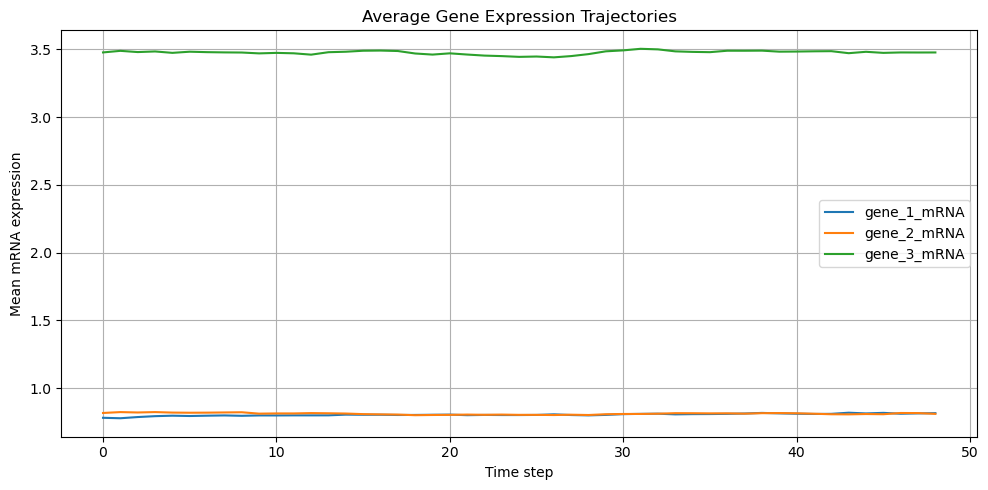

In [813]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file into a DataFrame

# Group by time and average across all cells
mean_traj = df.groupby("time_step")[["gene_1_mRNA", "gene_2_mRNA", "gene_3_mRNA"]].mean()

# Plot
plt.figure(figsize=(10, 5))
for gene in mean_traj.columns:
    plt.plot(mean_traj.index, mean_traj[gene], label=gene)

plt.xlabel("Time step")
plt.ylabel("Mean mRNA expression")
plt.title("Average Gene Expression Trajectories")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [314]:
import numpy as np
import pandas as pd
from itertools import combinations

# Parameters
n_perms = 20000
genes = expr_t1_all.columns.tolist()  # List of gene names
mi_null_distributions = {}            # Store null MI for each pair

# Loop over all unique gene pairs
for gene_i, gene_j in combinations(genes, 2):
    mi_null = []

    for _ in range(n_perms):
        # Shuffle gene_j
        Y_shuffled = expr_t2_all[gene_j].sample(frac=1).reset_index(drop=True)
        df_perm = expr_t2_all.assign(gj_perm=Y_shuffled)

        # Compute MI between gene_i and shuffled gene_j
        mi_val = mutual_information_discrete(
            *calc_joint_marginal(df_perm, gene_i, 'gj_perm'),
            log_base=2
        )
        mi_null.append(mi_val)

    # Store null distribution
    mi_null_distributions[(gene_i, gene_j)] = mi_null

    #print mi values
    original_mi = mi_matrix_t2.loc[gene_i, gene_j]
    print(f"Pair ({gene_i}, {gene_j}) → Null MI mean: {np.mean(mi_null):.4f}, Original MI: {original_mi:.4f}")


Pair (gene_1_mRNA, gene_2_mRNA) → Null MI mean: 0.0032, Original MI: 0.0053


In [ ]:
empirical_p_values = {}

for (gene_i, gene_j), mi_null in mi_null_distributions.items():
    mi_null = np.array(mi_null)

    # Get observed MI from original matrix
    observed_mi = mi_matrix_t1.loc[gene_i, gene_j]


    # Count how many null MI values are >= observed MI
    count_extreme = np.sum(mi_null >= observed_mi)


    # Compute empirical p-value by Davison and Hinkley (1997)
    p_value = (count_extreme + 1) / (len(mi_null) + 1)

    # Store result
    empirical_p_values[(gene_i, gene_j)] = p_value

    # Optional: print summary
    print(f"Pair ({gene_i}, {gene_j}) → p-value: {p_value:.6f}, Extreme count: {count_extreme}")


Pair (gene_1_mRNA, gene_2_mRNA) → p-value: 0.009901, Extreme count: 0


In [89]:
#Step II: Ratio of mi_null to mi_twin (R= mi_null/mi_twin)
    #1. compute twin mi: mi of the difference of twins at t1
        #a. Δgene_1_mRNA= gene_1_mRNA_twin1(t₁) − gene_1_mRNA_twin2(t₁)
        #b. Δgene_2_mRNA= gene_2_mRNA_twin1(t1) − gene_2_mRNA_twin2(t2)
        #c. same for other genes
        #d. compute the mi between Δgene_n_mRNA pairs (Δgene_1_mRNA and Δgene_2_mRNA, etc.)
    #2. compute the null (random) mi at t1       
        #a. shuffle one side of the twin pairs (e.g., all twin2 cells)
        #b. form new pseudo-twin pairs by pairing each twin1 with a randomly selected twin2
        #c. compute Δgene_1_mRNA, Δgene_2_mRNA, and other genes for these new pairs
        #d. compute the mi between Δgene_n_mRNA pairs (Δgene_1_mRNA and Δgene_2_mRNA, etc.)
    #3. compute the ratio of mi_null to mi_twin

In [236]:
def compute_step_II_mi_ratio(df, t1, n_perms=1000, log_base=2):
    # Extract twin replicates at t1
    rep_0 = df[(df['time_step'] == t1) & (df['replicate'] == 1)].reset_index(drop=True)
    rep_1 = df[(df['time_step'] == t1) & (df['replicate'] == 2)].reset_index(drop=True)

    # Build gene list
    mRNA_cols = [col for col in df.columns if col.endswith("_mRNA")]
    gene_list = sorted(set('_'.join(col.split('_')[:2]) for col in mRNA_cols))

    # Compute Δ expression for true twin pairs
    delta_true = pd.DataFrame({
        f"Δ{gene}_mRNA": rep_0[f"{gene}_mRNA"] - rep_1[f"{gene}_mRNA"]
        for gene in gene_list
    })

    # Compute MI between Δ_gene pairs (true twin MI)
    mi_twin = {}
    for gene_i, gene_j in combinations(gene_list, 2):
        col_i = f"Δ{gene_i}_mRNA"
        col_j = f"Δ{gene_j}_mRNA"
        joint, x_prob, y_prob = calc_joint_marginal(delta_true, col_i, col_j)
        mi_val = mutual_information_discrete(joint, x_prob, y_prob, log_base)
        mi_twin[(gene_i, gene_j)] = mi_val

    # Compute null MI by shuffling twin2 and forming pseudo-pairs
    mi_null_mean = {}
    for gene_i, gene_j in combinations(gene_list, 2):
        col_i = f"{gene_i}_mRNA"
        col_j = f"{gene_j}_mRNA"
        mi_null = []

        for _ in range(n_perms):
            rep_1_shuffled = rep_1.sample(frac=1).reset_index(drop=True)
            delta_perm = pd.DataFrame({
                f"Δ{gene}_mRNA": rep_0[f"{gene}_mRNA"] - rep_1_shuffled[f"{gene}_mRNA"]
                for gene in [gene_i, gene_j]
            })

            joint, x_prob, y_prob = calc_joint_marginal(delta_perm, f"Δ{gene_i}_mRNA", f"Δ{gene_j}_mRNA")
            mi_val = mutual_information_discrete(joint, x_prob, y_prob, log_base)
            mi_null.append(mi_val)

        mi_null_mean[(gene_i, gene_j)] = np.mean(mi_null)

    # Compute ratio R = mi_null / mi_twin
    mi_ratios = {
        (gene_i, gene_j): mi_null_mean[(gene_i, gene_j)] / mi_twin[(gene_i, gene_j)]
        if mi_twin[(gene_i, gene_j)] > 0 else np.inf
        for (gene_i, gene_j) in mi_twin
    }

    # Print results
    for (gene_i, gene_j) in mi_twin:
        print(f"Pair ({gene_i}, {gene_j}) → MI_twin: {mi_twin[(gene_i, gene_j)]:.4f}, "
              f"MI_null_mean: {mi_null_mean[(gene_i, gene_j)]:.4f}, "
              f"R = {mi_ratios[(gene_i, gene_j)]:.4f}")

    return mi_twin, mi_null_mean, mi_ratios


In [240]:
mi_twin, mi_null_mean, mi_ratios = compute_step_II_mi_ratio(df, t1=15, n_perms=1)

Pair (gene_1, gene_2) → MI_twin: 0.0243, MI_null_mean: 0.0226, R = 0.9295
Pair (gene_1, gene_3) → MI_twin: 0.0252, MI_null_mean: 0.0241, R = 0.9540
Pair (gene_2, gene_3) → MI_twin: 0.0351, MI_null_mean: 0.0541, R = 1.5436


In [241]:
for pair, mi in mi_twin.items():
    print(f"{pair}: MI_twin = {mi:.4f}, MI_null = {mi_null_mean[pair]:.4f}, R = {mi_null_mean[pair]/mi:.4f}")


('gene_1', 'gene_2'): MI_twin = 0.0243, MI_null = 0.0226, R = 0.9295
('gene_1', 'gene_3'): MI_twin = 0.0252, MI_null = 0.0241, R = 0.9540
('gene_2', 'gene_3'): MI_twin = 0.0351, MI_null = 0.0541, R = 1.5436


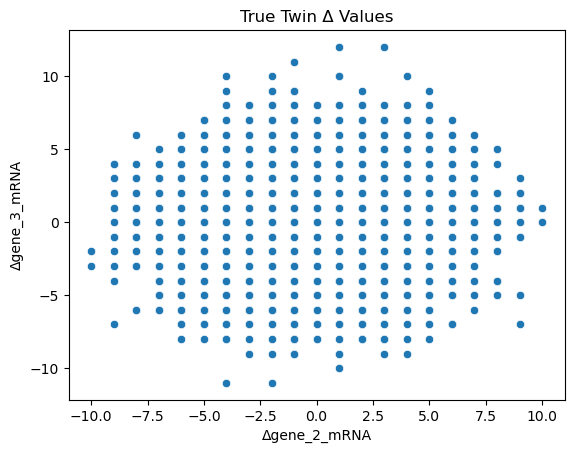

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

t1 = 5

# Extract twin replicates
rep_0 = df[(df['time_step'] == t1) & (df['replicate'] == 1)].reset_index(drop=True)
rep_1 = df[(df['time_step'] == t1) & (df['replicate'] == 2)].reset_index(drop=True)

# Identify gene names
mRNA_cols = [col for col in df.columns if col.endswith("_mRNA")]
gene_list = sorted(set('_'.join(col.split('_')[:2]) for col in mRNA_cols))

# Reconstruct Δ values
delta_true = pd.DataFrame({
    f"Δ{gene}_mRNA": rep_0[f"{gene}_mRNA"] - rep_1[f"{gene}_mRNA"]
    for gene in gene_list
})

sns.scatterplot(x=delta_true["Δgene_2_mRNA"], y=delta_true["Δgene_3_mRNA"])
plt.title("True Twin Δ Values")
plt.show()



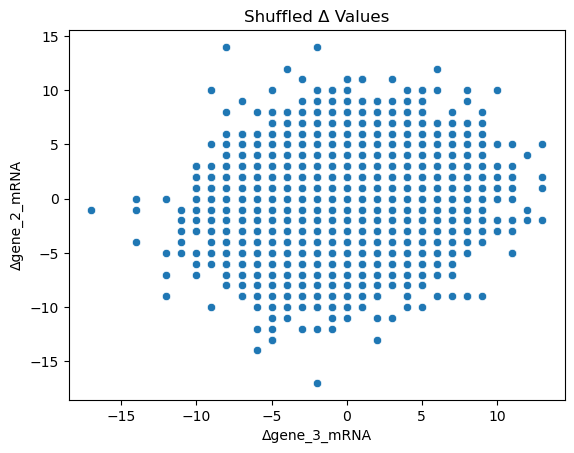

In [243]:
rep_1_shuffled = rep_1.sample(frac=1).reset_index(drop=True)
delta_perm = pd.DataFrame({
    "Δgene_1_mRNA": rep_0["gene_1_mRNA"] - rep_1_shuffled["gene_1_mRNA"],
    "Δgene_2_mRNA": rep_0["gene_2_mRNA"] - rep_1_shuffled["gene_2_mRNA"],
    "Δgene_3_mRNA": rep_0["gene_3_mRNA"] - rep_1_shuffled["gene_3_mRNA"]
})
sns.scatterplot(x=delta_perm["Δgene_3_mRNA"], y=delta_perm["Δgene_2_mRNA"])
plt.title("Shuffled Δ Values")
plt.show()


In [231]:
p_val = np.mean([mi >= mi_twin[('gene_1', 'gene_2')] for mi in mi_null])
print(p_val)

0.0


In [ ]:
# Assuming rep_0 and rep_1 are twin DataFrames
# and rep_1_shuffled is the same rep_1 after shuffling:

delta1_twin = rep_0["gene_1_mRNA"] - rep_1["gene_1_mRNA"]
delta2_twin = rep_0["gene_2_mRNA"] - rep_1["gene_2_mRNA"]

delta1_null = rep_0["gene_1_mRNA"] - rep_1_shuffled["gene_1_mRNA"]
delta2_null = rep_0["gene_2_mRNA"] - rep_1_shuffled["gene_2_mRNA"]

import numpy as np
from scipy.stats import entropy

def compute_entropy(vals, bins=50):
    p, _ = np.histogram(vals, bins=bins, density=True)
    return entropy(p + 1e-9)   # add tiny constant to avoid log(0)

def compute_joint_entropy(x, y, bins=50):
    pxy, _, _ = np.histogram2d(x, y, bins=bins, density=True)
    return entropy(pxy.ravel() + 1e-9)

for label, (d1, d2) in [
    ("Twin", (delta1_twin, delta2_twin)),
    ("Null", (delta1_null, delta2_null))
]:
    H1  = compute_entropy(d1, bins=50)
    H2  = compute_entropy(d2, bins=50)
    H12 = compute_joint_entropy(d1, d2, bins=50)
    print(f"{label}: H1={H1:.4f}, H2={H2:.4f}, H12={H12:.4f}")



Twin: H1=1.6940, H2=2.4203, H12=4.1024
Null: H1=1.8574, H2=2.6465, H12=4.4852


In [ ]:
import numpy as np
from scipy.stats import entropy

def compute_entropy(vals, bins=50):
    p, _ = np.histogram(vals, bins=bins, density=True)
    return entropy(p + 1e-9)

def compute_joint_entropy(x, y, bins=50):
    pxy, _, _ = np.histogram2d(x, y, bins=bins, density=True)
    return entropy(pxy.ravel() + 1e-9)

def compute_mi_from_entropies(H1, H2, H12):
    return H1 + H2 - H12

def compute_nmi(delta1, delta2, bins=50):
    H1  = compute_entropy(delta1, bins)
    H2  = compute_entropy(delta2, bins)
    H12 = compute_joint_entropy(delta1, delta2, bins)
    I   = compute_mi_from_entropies(H1, H2, H12)

    nmi_min = I / min(H1, H2)
    nmi_2   = 2 * I / (H1 + H2)
    nmi_gm  = I / np.sqrt(H1 * H2)
    nmi_j   = I / H12

    return {
        'MI': I,
        'NMI_min': nmi_min,
        'NMI_2': nmi_2,
        'NMI_gm': nmi_gm,
        'NMI_joint': nmi_j,
        'H1': H1, 'H2': H2, 'H12': H12
    }

delta1_twin = rep_0["gene_1_mRNA"] - rep_1["gene_1_mRNA"]
delta2_twin = rep_0["gene_2_mRNA"] - rep_1["gene_2_mRNA"]

delta1_null = rep_0["gene_1_mRNA"] - rep_1_shuffled["gene_1_mRNA"]
delta2_null = rep_0["gene_2_mRNA"] - rep_1_shuffled["gene_2_mRNA"]

# Compute NMI metrics
metrics_twin = compute_nmi(delta1_twin, delta2_twin, bins=50)
metrics_null = compute_nmi(delta1_null, delta2_null, bins=50)

# Compare
for key in ['MI','NMI_min','NMI_2','NMI_gm','NMI_joint']:
    print(f"{key}: Twin={metrics_twin[key]:.4f}, Null={metrics_null[key]:.4f}")



MI: Twin=0.0119, Null=0.0187
NMI_min: Twin=0.0070, Null=0.0101
NMI_2: Twin=0.0058, Null=0.0083
NMI_gm: Twin=0.0059, Null=0.0084
NMI_joint: Twin=0.0029, Null=0.0042
